In [2]:
# Importations de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import sys
import warnings
warnings.filterwarnings('ignore')

# Gestion des imports optionnels
try:
    import featuretools as ft
    USE_FEATURE_TOOLS = True
except ImportError:
    USE_FEATURE_TOOLS = False
    print("Info: featuretools non installé - certaines fonctionnalités avancées seront limitées")

# Préprocessing et évaluation
from sklearn.preprocessing import (StandardScaler, 
                                MinMaxScaler, 
                                FunctionTransformer,
                                PolynomialFeatures)
from sklearn.model_selection import (train_test_split, 
                                   cross_val_score, 
                                   GridSearchCV,
                                   TimeSeriesSplit)
from sklearn.metrics import (mean_squared_error, 
                           r2_score,
                           mean_absolute_error,
                           mean_absolute_percentage_error)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modèles
from sklearn.linear_model import (LinearRegression, 
                                Ridge, 
                                LassoCV,
                                ElasticNet,
                                BayesianRidge)
from sklearn.ensemble import (RandomForestRegressor,
                            GradientBoostingRegressor,
                            StackingRegressor,
                            VotingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

# Feature selection
from sklearn.feature_selection import (RFECV, 
                                     SelectFromModel,
                                     SelectKBest, 
                                     f_regression,
                                     mutual_info_regression)

# Configuration
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Packages importés avec succès")
if not USE_FEATURE_TOOLS:
    print("ℹ️ Featuretools non disponible - le feature engineering automatique sera limité")

Info: featuretools non installé - certaines fonctionnalités avancées seront limitées
✅ Packages importés avec succès
ℹ️ Featuretools non disponible - le feature engineering automatique sera limité


In [4]:
def load_and_validate_data(path):
    """Charge et valide les données avec vérifications approfondies"""
    try:
        df = pd.read_csv(path, sep=';', parse_dates=['dataloadingdate'], dayfirst=True)
        
        # Vérifications de base
        assert not df.empty, "Le fichier est vide"
        assert 'Montant' in df.columns, "Colonne target 'Montant' manquante"
        
        # Analyse des données manquantes
        missing = df.isnull().sum()
        if missing.any():
            print("⚠️ Valeurs manquantes détectées:")
            display(missing[missing > 0])
        
        # Vérification des doublons
        dupes = df.duplicated().sum()
        if dupes > 0:
            print(f"⚠️ {dupes} doublons détectés - suppression...")
            df = df.drop_duplicates()
        
        print(f"✅ Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")
        return df
    
    except Exception as e:
        print(f"❌ Erreur de chargement : {str(e)}")
        raise

# Utilisation
df = load_and_validate_data(r"C:\Users\zizou\OneDrive\Desktop\stage 3ème\day 2\csvfiles\dataframefinale.csv")
display(df.head(2))

⚠️ 374 doublons détectés - suppression...
✅ Données chargées : 19621 lignes, 13 colonnes


,dataloadingdate,Jour,Mois,NumeroSemaine,Trimestre,JourSemaineNum,JourSemaine,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,2025-07-01,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0000,1.5000,62.0000,7.6000
1,2025-07-01,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",291.0000,0.3000,183.0000,7.5000


In [5]:
def advanced_feature_engineering(df):
    """Crée des features avancées avec ou sans featuretools"""
    # Features de base
    df['Taux_x_Echeance'] = df['Taux'] * df['Echéance']
    df['Log_Titres'] = np.log1p(df['Nombre de Titres'])
    
    # Features temporelles
    if 'dataloadingdate' in df.columns:
        df['Annee'] = df['dataloadingdate'].dt.year
        df['Mois_Jour'] = df['dataloadingdate'].dt.strftime('%m-%d')
    
    # Feature engineering avancé conditionnel
    if USE_FEATURE_TOOLS:
        print("Création de features avancées avec featuretools...")
        es = ft.EntitySet(id='data')
        es = es.entity_from_dataframe(entity_id='main', dataframe=df, index='id')
        feature_matrix, features = ft.dfs(entityset=es, target_entity='main')
        df = pd.concat([df, feature_matrix], axis=1)
    else:
        print("Création de features de base (sans featuretools)")
        df['Taux_div_Titres'] = df['Taux'] / (df['Nombre de Titres'] + 1)
        df['Interaction_Complexe'] = df['Taux'] * np.sqrt(df['Echéance'])
    
    return df

# Application
df = advanced_feature_engineering(df)
print("\nNouvelles colonnes créées:")
print([col for col in df.columns if col not in ['Montant', 'Libellé', 'ISIN']])

Création de features de base (sans featuretools)

Nouvelles colonnes créées:
['dataloadingdate', 'Jour', 'Mois', 'NumeroSemaine', 'Trimestre', 'JourSemaineNum', 'JourSemaine', 'Nombre de Titres', 'Echéance', 'Taux', 'Taux_x_Echeance', 'Log_Titres', 'Annee', 'Mois_Jour', 'Taux_div_Titres', 'Interaction_Complexe']


In [6]:
def prepare_data(df, target='Montant', test_size=0.2):
    """Prépare les données pour l'entraînement"""
    # Séparation features/target
    X = df.drop(columns=[target, 'Libellé', 'ISIN'], errors='ignore')
    y = df[target]
    
    # Conversion des catégorielles
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    if not cat_cols.empty:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    
    # Split des données
    if 'dataloadingdate' in X.columns:
        print("➡️ Split temporel détecté")
        split_idx = int(len(X) * (1 - test_size))
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    else:
        print("➡️ Split aléatoire")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42)
    
    # Vérification finale
    print(f"\nShapes finaux:")
    print(f"- X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"- X_test: {X_test.shape}, y_test: {y_test.shape}")
    
    return X_train, X_test, y_train, y_test

# Application
X_train, X_test, y_train, y_test = prepare_data(df)

➡️ Split temporel détecté

Shapes finaux:
- X_train: (15696, 375), y_train: (15696,)
- X_test: (3925, 375), y_test: (3925,)


In [8]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel
import numpy as np

def build_model_pipeline(with_feature_selection=True):
    """Construit un pipeline complet avec options configurables"""
    # Préprocessing numérique
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False))
    ])
    
    # Préprocessing catégoriel (au cas où)
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    # Sélecteur de colonnes
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
            ('cat', categorical_transformer, make_column_selector(dtype_include=['object', 'category']))
        ])
    
    # Construction du pipeline
    steps = [
        ('preprocessor', preprocessor)
    ]
    
    if with_feature_selection:
        steps.append(('feature_selection', SelectFromModel(
            GradientBoostingRegressor(random_state=42), threshold='median')))
    
    steps.append(('model', GradientBoostingRegressor(random_state=42)))
    
    return Pipeline(steps)

# Initialisation
model_pipeline = build_model_pipeline()
print("✅ Pipeline créé avec succès")
print("\nStructure du pipeline:")
model_pipeline

✅ Pipeline créé avec succès

Structure du pipeline:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000174686F7740>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000174686F7770>)])),
                ('feature_selection',
                 SelectFromModel(estimator=GradientBoostingRegressor(random_state=42),
                                 threshold='median')),
                ('model', GradientBoostingRegressor(random_state=42))])

In [9]:
def train_and_optimize(model, X_train, y_train):
    """Effectue l'entraînement et l'optimisation des hyperparamètres"""
    # Paramètres pour GridSearchCV
    param_grid = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [3, 5],
        'model__subsample': [0.8, 1.0]
    }
    
    # Configuration de la validation croisée
    cv_strategy = TimeSeriesSplit(n_splits=5) if 'dataloadingdate' in X_train.columns else 5
    
    # Recherche d'hyperparamètres
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=2
    )
    
    print("Début de l'entraînement...")
    grid_search.fit(X_train, y_train)
    
    # Résultats
    print("\nMeilleurs paramètres trouvés:")
    print(grid_search.best_params_)
    
    return grid_search.best_estimator_

# Application
best_model = train_and_optimize(model_pipeline, X_train, y_train)

Début de l'entraînement...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Meilleurs paramètres trouvés:
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


📊 Métriques de performance:


RMSE        5.3458
MAE         2.2601
R2          0.5643
MAPE        1.0402
MaxError   64.5534
Name: Valeur, dtype: float64

⚠️ Impossible d'afficher les importances: All arrays must be of the same length


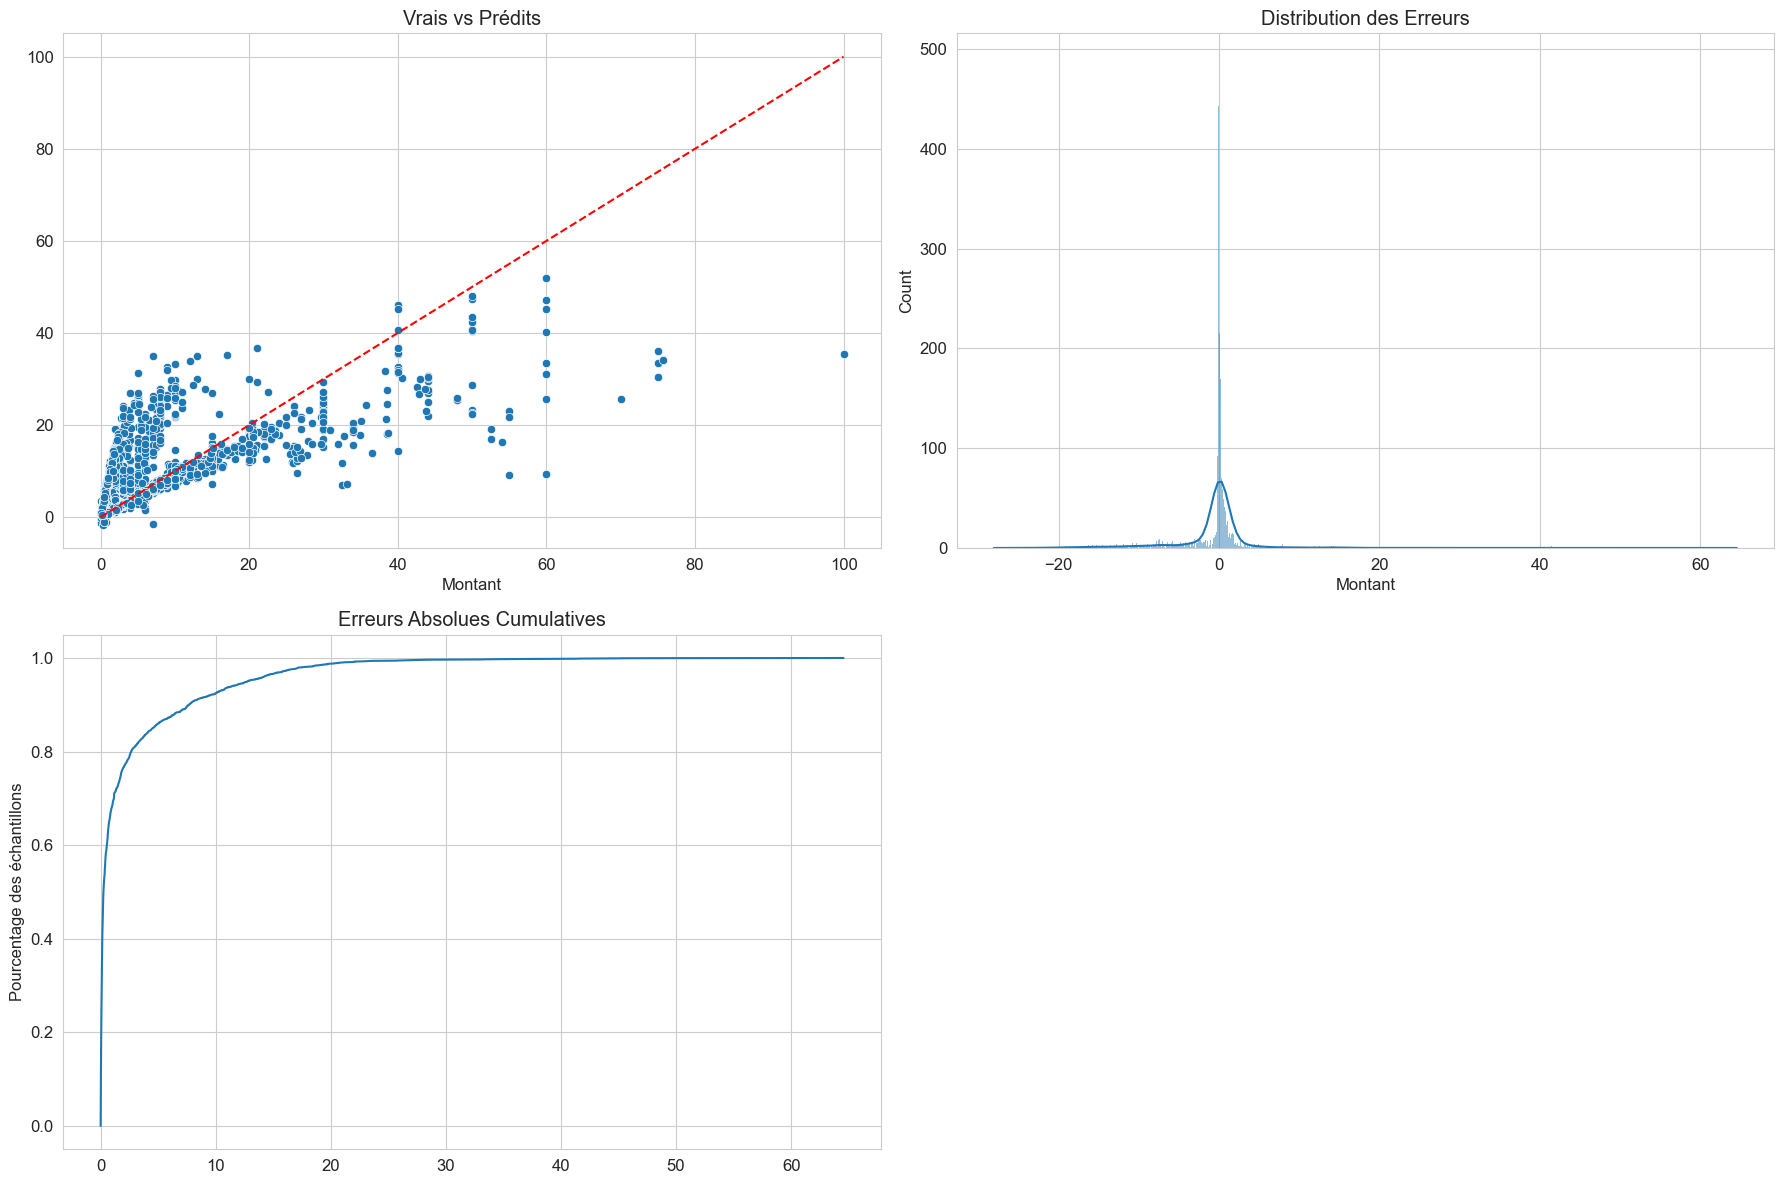

In [10]:
def comprehensive_evaluation(model, X_test, y_test):
    """Évaluation complète avec métriques et visualisations"""
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    metrics = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'MaxError': np.max(np.abs(y_test - y_pred))
    }
    
    # Affichage des métriques
    print("📊 Métriques de performance:")
    display(pd.Series(metrics).rename('Valeur'))
    
    # Visualisations
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Scatter plot réel vs prédit
    sns.scatterplot(x=y_test, y=y_pred, ax=axes[0,0])
    axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[0,0].set_title('Vrais vs Prédits')
    
    # 2. Distribution des erreurs
    sns.histplot(y_test - y_pred, kde=True, ax=axes[0,1])
    axes[0,1].set_title('Distribution des Erreurs')
    
    # 3. Erreurs cumulatives
    sorted_errors = np.sort(np.abs(y_test - y_pred))
    axes[1,0].plot(sorted_errors, np.linspace(0, 1, len(sorted_errors)))
    axes[1,0].set_title('Erreurs Absolues Cumulatives')
    axes[1,0].set_ylabel('Pourcentage des échantillons')
    
    # 4. Feature importance
    try:
        if hasattr(model.named_steps['model'], 'feature_importances_'):
            importances = model.named_steps['model'].feature_importances_
            features = X_test.columns
            importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
            sns.barplot(data=importance_df.nlargest(10, 'Importance'), 
                       x='Importance', y='Feature', ax=axes[1,1])
            axes[1,1].set_title('Top 10 Features Importantes')
    except Exception as e:
        print(f"⚠️ Impossible d'afficher les importances: {str(e)}")
        axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return metrics

# Application
final_metrics = comprehensive_evaluation(best_model, X_test, y_test)

In [12]:
def save_and_deploy(model, model_name, X_test, y_test):
    """Sauvegarde le modèle et crée des artefacts pour le déploiement"""
    import joblib
    import json
    from datetime import datetime
    
    # Création du dossier de sauvegarde
    save_dir = f"model_artifacts_{datetime.now().strftime('%Y%m%d_%H%M')}"
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. Sauvegarde du modèle
    model_path = os.path.join(save_dir, f"{model_name}.pkl")
    joblib.dump(model, model_path)
    
    # 2. Sauvegarde des métriques
    metrics = comprehensive_evaluation(model, X_test, y_test)
    with open(os.path.join(save_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f)
    
    # 3. Exemple de données pour test
    sample_data = X_test.iloc[:5].to_dict(orient='records')
    with open(os.path.join(save_dir, 'sample_data.json'), 'w') as f:
        json.dump(sample_data, f)
    
    # 4. Requirements
    with open(os.path.join(save_dir, 'requirements.txt'), 'w') as f:
        f.write("\n".join([
            "scikit-learn>=1.0.0",
            "pandas>=1.0.0",
            "numpy>=1.0.0"
        ]))
    
    print(f"✅ Modèle et artefacts sauvegardés dans: {save_dir}")
    return save_dir

# Application
artifacts_dir = save_and_deploy(best_model, "montant_predictor", X_test, y_test)

NameError: name 'os' is not defined

In [13]:
def analyze_and_recommend(model, X_test, y_test, metrics):
    """Analyse approfondie des erreurs et génère des recommandations"""
    # Analyse des pires prédictions
    errors = y_test - model.predict(X_test)
    worst_idx = np.abs(errors).nlargest(5).index
    worst_samples = X_test.loc[worst_idx].copy()
    worst_samples['Vrai'] = y_test.loc[worst_idx]
    worst_samples['Prédit'] = model.predict(X_test.loc[worst_idx])
    worst_samples['Erreur'] = errors.loc[worst_idx]
    
    print("\n🔎 Top 5 des pires prédictions:")
    display(worst_samples)
    
    # Recommandations automatiques
    recommendations = []
    
    if metrics['MAPE'] > 15:
        recommendations.append("Envisager des transformations logarithmiques sur la target")
    
    if metrics['MaxError'] > 3 * metrics['RMSE']:
        recommendations.append("Implémenter un traitement spécial pour les valeurs extrêmes")
    
    if metrics['R2'] < 0.8:
        recommendations.append("Tester des modèles plus complexes ou ajouter des features")
    
    if not recommendations:
        recommendations.append("Le modèle montre de bonnes performances - envisager un déploiement")
    
    print("\n💡 Recommandations:")
    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec}")
    
    return worst_samples

# Application
worst_predictions = analyze_and_recommend(best_model, X_test, y_test, final_metrics)


🔎 Top 5 des pires prédictions:


,dataloadingdate,Jour,Mois,NumeroSemaine,Trimestre,JourSemaineNum,Nombre de Titres,Echéance,Taux,Taux_x_Echeance,Log_Titres,Annee,Taux_div_Titres,Interaction_Complexe,JourSemaine_Monday,JourSemaine_Thursday,JourSemaine_Tuesday,JourSemaine_Wednesday,Mois_Jour_01-03,Mois_Jour_01-04,Mois_Jour_01-05,Mois_Jour_01-06,Mois_Jour_01-07,Mois_Jour_01-08,Mois_Jour_01-09,Mois_Jour_01-10,Mois_Jour_01-11,Mois_Jour_01-12,Mois_Jour_01-13,Mois_Jour_01-14,Mois_Jour_01-15,Mois_Jour_01-16,Mois_Jour_01-17,Mois_Jour_01-18,Mois_Jour_01-19,Mois_Jour_01-20,Mois_Jour_01-21,Mois_Jour_01-22,Mois_Jour_01-23,Mois_Jour_01-24,Mois_Jour_01-25,Mois_Jour_01-26,Mois_Jour_01-27,Mois_Jour_01-28,Mois_Jour_01-29,Mois_Jour_01-30,Mois_Jour_01-31,Mois_Jour_02-01,Mois_Jour_02-02,Mois_Jour_02-03,Mois_Jour_02-04,Mois_Jour_02-05,Mois_Jour_02-06,Mois_Jour_02-07,Mois_Jour_02-08,Mois_Jour_02-09,Mois_Jour_02-10,Mois_Jour_02-11,Mois_Jour_02-12,Mois_Jour_02-13,Mois_Jour_02-14,Mois_Jour_02-15,Mois_Jour_02-16,Mois_Jour_02-17,Mois_Jour_02-18,Mois_Jour_02-19,Mois_Jour_02-20,Mois_Jour_02-21,Mois_Jour_02-22,Mois_Jour_02-23,Mois_Jour_02-24,Mois_Jour_02-25,Mois_Jour_02-26,Mois_Jour_02-27,Mois_Jour_02-28,Mois_Jour_02-29,Mois_Jour_03-01,Mois_Jour_03-02,Mois_Jour_03-03,Mois_Jour_03-04,Mois_Jour_03-05,Mois_Jour_03-06,Mois_Jour_03-07,Mois_Jour_03-08,Mois_Jour_03-09,Mois_Jour_03-10,Mois_Jour_03-11,Mois_Jour_03-12,Mois_Jour_03-13,Mois_Jour_03-14,Mois_Jour_03-15,Mois_Jour_03-16,Mois_Jour_03-17,Mois_Jour_03-18,Mois_Jour_03-19,Mois_Jour_03-21,Mois_Jour_03-22,Mois_Jour_03-23,Mois_Jour_03-24,Mois_Jour_03-25,...,Mois_Jour_09-24,Mois_Jour_09-25,Mois_Jour_09-26,Mois_Jour_09-27,Mois_Jour_09-28,Mois_Jour_09-29,Mois_Jour_09-30,Mois_Jour_10-01,Mois_Jour_10-02,Mois_Jour_10-03,Mois_Jour_10-04,Mois_Jour_10-05,Mois_Jour_10-06,Mois_Jour_10-07,Mois_Jour_10-08,Mois_Jour_10-09,Mois_Jour_10-10,Mois_Jour_10-11,Mois_Jour_10-12,Mois_Jour_10-13,Mois_Jour_10-14,Mois_Jour_10-16,Mois_Jour_10-17,Mois_Jour_10-18,Mois_Jour_10-19,Mois_Jour_10-20,Mois_Jour_10-21,Mois_Jour_10-22,Mois_Jour_10-23,Mois_Jour_10-24,Mois_Jour_10-25,Mois_Jour_10-26,Mois_Jour_10-27,Mois_Jour_10-28,Mois_Jour_10-29,Mois_Jour_10-30,Mois_Jour_10-31,Mois_Jour_11-01,Mois_Jour_11-02,Mois_Jour_11-03,Mois_Jour_11-04,Mois_Jour_11-05,Mois_Jour_11-06,Mois_Jour_11-07,Mois_Jour_11-08,Mois_Jour_11-09,Mois_Jour_11-10,Mois_Jour_11-11,Mois_Jour_11-12,Mois_Jour_11-13,Mois_Jour_11-14,Mois_Jour_11-15,Mois_Jour_11-16,Mois_Jour_11-17,Mois_Jour_11-18,Mois_Jour_11-19,Mois_Jour_11-20,Mois_Jour_11-21,Mois_Jour_11-22,Mois_Jour_11-23,Mois_Jour_11-24,Mois_Jour_11-25,Mois_Jour_11-26,Mois_Jour_11-27,Mois_Jour_11-28,Mois_Jour_11-29,Mois_Jour_11-30,Mois_Jour_12-01,Mois_Jour_12-02,Mois_Jour_12-03,Mois_Jour_12-04,Mois_Jour_12-05,Mois_Jour_12-06,Mois_Jour_12-07,Mois_Jour_12-08,Mois_Jour_12-09,Mois_Jour_12-10,Mois_Jour_12-11,Mois_Jour_12-12,Mois_Jour_12-13,Mois_Jour_12-14,Mois_Jour_12-15,Mois_Jour_12-16,Mois_Jour_12-18,Mois_Jour_12-19,Mois_Jour_12-20,Mois_Jour_12-21,Mois_Jour_12-22,Mois_Jour_12-23,Mois_Jour_12-24,Mois_Jour_12-25,Mois_Jour_12-26,Mois_Jour_12-27,Mois_Jour_12-28,Mois_Jour_12-29,Mois_Jour_12-30,Mois_Jour_12-31,Vrai,Prédit,Erreur
19956,2024-12-31,31,12,1,4,1,99258.0000,35.0000,8.5000,297.5000,11.5055,2024,0.0001,50.2867,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F


💡 Recommandations:
1. Implémenter un traitement spécial pour les valeurs extrêmes
2. Tester des modèles plus complexes ou ajouter des features


In [14]:
def create_interactive_dashboard(X_test, y_test, model):
    """Crée un dashboard interactif avec Plotly"""
    try:
        import plotly.express as px
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        
        # Prédictions
        y_pred = model.predict(X_test)
        
        # Création du dashboard
        fig = make_subplots(rows=2, cols=2,
                          subplot_titles=('Vrais vs Prédits', 'Erreurs par Période',
                                        'Distribution des Erreurs', 'Features Importantes'))
        
        # 1. Scatter plot
        fig.add_trace(
            go.Scatter(x=y_test, y=y_pred, mode='markers'),
            row=1, col=1
        )
        
        # 2. Erreurs temporelles (si date disponible)
        if 'dataloadingdate' in X_test.columns:
            fig.add_trace(
                go.Scatter(x=X_test['dataloadingdate'], y=y_test - y_pred, mode='lines'),
                row=1, col=2
            )
        
        # 3. Histogramme des erreurs
        fig.add_trace(
            go.Histogram(x=y_test - y_pred),
            row=2, col=1
        )
        
        # 4. Feature importance
        try:
            if hasattr(model.named_steps['model'], 'feature_importances_'):
                importances = model.named_steps['model'].feature_importances_
                features = X_test.columns
                fig.add_trace(
                    go.Bar(x=importances, y=features, orientation='h'),
                    row=2, col=2
                )
        except:
            pass
        
        fig.update_layout(height=800, width=1000, title_text="Dashboard d'Analyse du Modèle")
        fig.show()
        
    except ImportError:
        print("Plotly non disponible - dashboard désactivé")

# Application
create_interactive_dashboard(X_test, y_test, best_model)